# Experiments: AdaBN Control Dataset

This notebook designs and runs experiments to support the claims:

1. **Claim 1**: The intensity-based shift is a reasonable approximation of a real distribution shift.
2. **Claim 2**: A standard CNN with Batch Normalisation performs well on the source domain.
3. **Claim 3**: Mismatched BN statistics lead to measurable degradation on the target domain.
4. **Claim 4**: Re-estimating BN statistics using AdaBN improves target-domain performance.

In [1]:
import os, copy, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import stats

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT = Path('')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Device: cpu
PyTorch version: 2.2.2


---
## Claim 1: The Intensity-Based Shift is a Reasonable Approximation of a Real Distribution Shift

We measure the statistical distance between source and target pixel intensity distributions using:
- Global mean and standard deviation per domain
- Effect size (Cohen's *d*: normalised mean difference)
- Kolmogorov–Smirnov test (tests whether two samples share the same distribution)

In [2]:
def load_pixels(domain_dir):
    # Return a flat float32 array in [0, 1] for all PNG images under domain_dir.
    pixels = []
    for img_path in sorted(Path(domain_dir).rglob('*.png')):
        arr = np.array(Image.open(img_path), dtype=np.float32) / 255.0
        pixels.append(arr.flatten())
    return np.concatenate(pixels)

src_pixels = load_pixels(ROOT / 'source')
tgt_pixels = load_pixels(ROOT / 'target')

src_mean, src_std = src_pixels.mean(), src_pixels.std()
tgt_mean, tgt_std = tgt_pixels.mean(), tgt_pixels.std()

mean_shift = tgt_mean - src_mean
pooled_std = np.sqrt((src_std**2 + tgt_std**2) / 2)
cohens_d   = mean_shift / pooled_std

rng   = np.random.default_rng(SEED)
idx_s = rng.choice(len(src_pixels), size=20_000, replace=False)
idx_t = rng.choice(len(tgt_pixels), size=20_000, replace=False)
ks_stat, ks_p = stats.ks_2samp(src_pixels[idx_s], tgt_pixels[idx_t])

print(f'Source  mean={src_mean:.4f}  std={src_std:.4f}  N={len(src_pixels):,}')
print(f'Target  mean={tgt_mean:.4f}  std={tgt_std:.4f}  N={len(tgt_pixels):,}')
print()
print(f'Mean shift  : {mean_shift:.4f}')
print(f"Cohen's d   : {cohens_d:.2f}  (|d| > 0.8 is 'large')")
print(f'KS statistic: {ks_stat:.4f}')
print(f'KS p-value  : {ks_p:.2e}  (p < 0.05 rejects same-distribution hypothesis)')

Source  mean=0.4980  std=0.1229  N=3,072,000
Target  mean=0.7968  std=0.1582  N=3,072,000

Mean shift  : 0.2988
Cohen's d   : 2.11  (|d| > 0.8 is 'large')
KS statistic: 0.7071
KS p-value  : 0.00e+00  (p < 0.05 rejects same-distribution hypothesis)


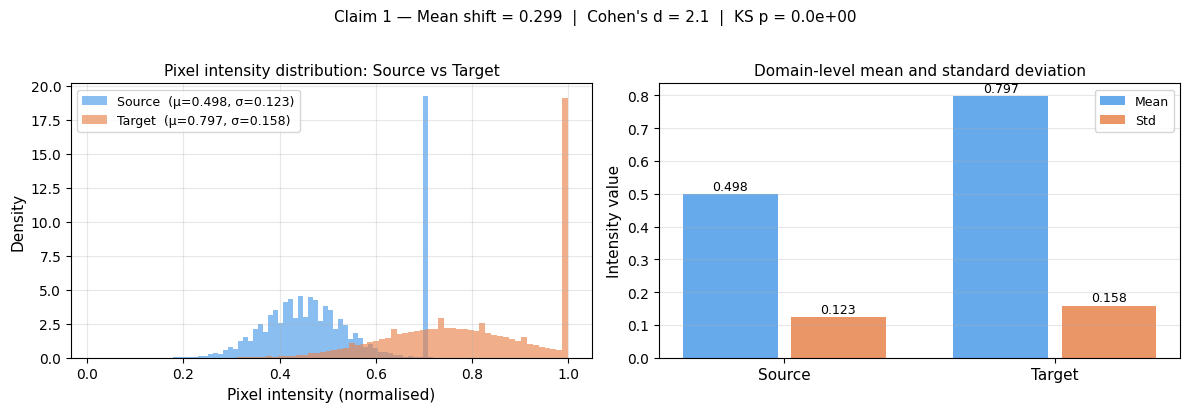

Saved: figures/claim1_domain_shift.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pixel intensity histograms
ax = axes[0]
ax.hist(src_pixels, bins=80, alpha=0.65, density=True, color='#4c9be8',
        label=f'Source  (μ={src_mean:.3f}, σ={src_std:.3f})')
ax.hist(tgt_pixels, bins=80, alpha=0.65, density=True, color='#e8844c',
        label=f'Target  (μ={tgt_mean:.3f}, σ={tgt_std:.3f})')
ax.set_xlabel('Pixel intensity (normalised)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Pixel intensity distribution: Source vs Target', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Per-domain statistics bar chart
ax = axes[1]
x  = np.arange(2)
b1 = ax.bar(x - 0.2, [src_mean, tgt_mean], 0.35, label='Mean', color='#4c9be8', alpha=0.85)
b2 = ax.bar(x + 0.2, [src_std,  tgt_std ], 0.35, label='Std',  color='#e8844c', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(['Source', 'Target'], fontsize=11)
ax.set_ylabel('Intensity value', fontsize=11)
ax.set_title('Domain-level mean and standard deviation', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
            f'{h:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle(
    f"Claim 1 — Mean shift = {mean_shift:.3f}  |  Cohen's d = {cohens_d:.1f}  |  KS p = {ks_p:.1e}",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'claim1_domain_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/claim1_domain_shift.png')

**Interpretation:** The KS test rejects the hypothesis that source and target are drawn from the same
distribution (p ≪ 0.05). Cohen's *d* >> 0.8 indicates a large effect. The shift is therefore both
statistically significant and practically large, confirming that the controlled shift is a non-trivial approximation of a real distribution shift.

---
## Dataset and Model Setup (Claims 2–4)

A `ShapeDataset` class loads images by class label from the control dataset.
A three-block CNN (`Conv-BN-ReLU-Pool × 3`) provides three Batch Normalisation layers whose
BN running statistics can be inspected and replaced.

In [4]:
class ShapeDataset(Dataset):
    # PNG images organised as class_<i>_<name>/ sub-folders inside a domain root.
    def __init__(self, root_dir):
        self.samples = []
        for class_dir in sorted(Path(root_dir).iterdir()):
            if not class_dir.is_dir():
                continue
            label = int(class_dir.name.split('_')[1])
            for img_path in sorted(class_dir.glob('*.png')):
                self.samples.append((str(img_path), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = transforms.ToTensor()(Image.open(path).convert('L'))  # [1, 32, 32] in [0, 1]
        return img, label


class SimpleCNN(nn.Module):
    # Three-block CNN for 32x32 greyscale images with three BN layers.
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,  16, 3, padding=1), nn.BatchNorm2d(16),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128), nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def evaluate(model, loader, device):
    # Returns accuracy in [0, 1] using model.eval() (uses BN running statistics).
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds   = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)
    return correct / total


print('ShapeDataset, SimpleCNN, and evaluate() defined.')

ShapeDataset, SimpleCNN, and evaluate() defined.


In [5]:
src_full = ShapeDataset(ROOT / 'source')
tgt_full = ShapeDataset(ROOT / 'target')

gen = torch.Generator().manual_seed(SEED)

# Source: 80 % train / 20 % test
n_src_train = int(0.8 * len(src_full))
src_train, src_test = random_split(src_full, [n_src_train, len(src_full) - n_src_train], generator=gen)

# Target: 80 % for AdaBN stat estimation / 20 % held-out test
n_tgt_adapt = int(0.8 * len(tgt_full))
tgt_adapt, tgt_test = random_split(tgt_full, [n_tgt_adapt, len(tgt_full) - n_tgt_adapt], generator=gen)

src_train_loader = DataLoader(src_train, batch_size=64, shuffle=True,  num_workers=0)
src_test_loader  = DataLoader(src_test,  batch_size=64, shuffle=False, num_workers=0)
tgt_adapt_loader = DataLoader(tgt_adapt, batch_size=64, shuffle=False, num_workers=0)
tgt_test_loader  = DataLoader(tgt_test,  batch_size=64, shuffle=False, num_workers=0)

print(f'Source train: {len(src_train):4d} images')
print(f'Source test : {len(src_test):4d} images')
print(f'Target adapt: {len(tgt_adapt):4d} images  (for AdaBN stat estimation)')
print(f'Target test : {len(tgt_test):4d} images  (held out for evaluation)')

Source train: 2400 images
Source test :  600 images
Target adapt: 2400 images  (for AdaBN stat estimation)
Target test :  600 images  (held out for evaluation)


---
## Claim 2: A Standard CNN with Batch Normalisation Performs Well on the Source Domain

We train `SimpleCNN` on the source training split and evaluate on the held-out source test split.

In [6]:
model     = SimpleCNN(num_classes=3).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

N_EPOCHS = 25
train_losses, train_accs = [], []

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    run_loss, correct, total = 0.0, 0, 0
    for x, y in src_train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * x.size(0)
        correct  += (out.detach().argmax(1) == y).sum().item()
        total    += y.size(0)
    train_losses.append(run_loss / total)
    train_accs.append(correct / total)
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:02d}/{N_EPOCHS}  loss={train_losses[-1]:.4f}  '
              f'train_acc={train_accs[-1]*100:.1f}%')

src_test_acc = evaluate(model, src_test_loader, DEVICE)
print(f'\nSource test accuracy: {src_test_acc*100:.1f}%')

Epoch 01/25  loss=0.3810  train_acc=84.2%
Epoch 05/25  loss=0.0009  train_acc=100.0%
Epoch 10/25  loss=0.0002  train_acc=100.0%
Epoch 15/25  loss=0.0001  train_acc=100.0%
Epoch 20/25  loss=0.0001  train_acc=100.0%
Epoch 25/25  loss=0.0000  train_acc=100.0%

Source test accuracy: 100.0%


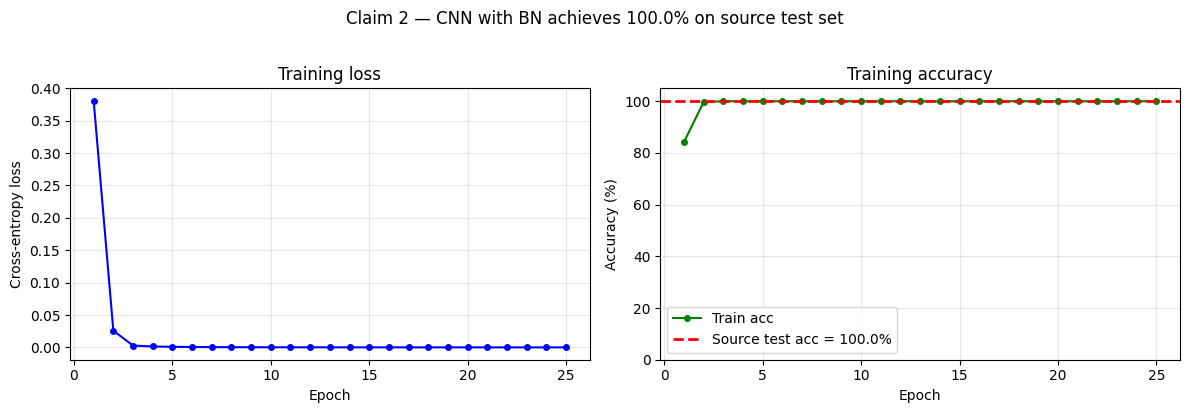

Saved: figures/claim2_source_accuracy.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, N_EPOCHS + 1)

ax = axes[0]
ax.plot(epochs, train_losses, 'b-o', markersize=4)
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-entropy loss')
ax.set_title('Training loss'); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(epochs, [a * 100 for a in train_accs], 'g-o', markersize=4, label='Train acc')
ax.axhline(src_test_acc * 100, color='red', ls='--', lw=2,
           label=f'Source test acc = {src_test_acc*100:.1f}%')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)'); ax.set_ylim([0, 105])
ax.set_title('Training accuracy'); ax.grid(alpha=0.3); ax.legend()

plt.suptitle(f'Claim 2 — CNN with BN achieves {src_test_acc*100:.1f}% on source test set',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'claim2_source_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/claim2_source_accuracy.png')

---
## Claim 3: Mismatched BN Statistics Lead to Measurable Degradation on the Target Domain

The source-trained model is evaluated on **target** images in `eval()` mode.
In this mode PyTorch BN uses the **source-domain** `running_mean` / `running_var` accumulated
during training — no weights change, only the input distribution has shifted.

In [8]:
tgt_acc_src_bn = evaluate(model, tgt_test_loader, DEVICE)

print(f'Source test acc  (source BN stats): {src_test_acc*100:.1f}%')
print(f'Target test acc  (source BN stats): {tgt_acc_src_bn*100:.1f}%')
print(f'Accuracy drop                     : {(src_test_acc - tgt_acc_src_bn)*100:.1f} pp')

Source test acc  (source BN stats): 100.0%
Target test acc  (source BN stats): 31.3%
Accuracy drop                     : 68.7 pp


---
## Claim 4: Re-estimating BN Statistics Using AdaBN Improves Target-Domain Performance

**AdaBN procedure** (Li et al., 2016):
1. Deep-copy the model (all weights fixed, source BN stats preserved).
2. Reset each BN layer's `running_mean` and `running_var` to their initial defaults.
3. Set `momentum = None` → PyTorch switches to cumulative moving average (exact statistics over all batches).
4. Pass the target adaptation split through in `train()` mode (no gradients — BN stats update only).
5. Evaluate on the held-out target test split with `eval()` using the newly estimated target statistics.

In [9]:
def apply_adabn(model, adapt_loader, device):
    # Re-estimate BN running stats from unlabelled target data; all weights remain fixed.
    adapted = copy.deepcopy(model)
    for m in adapted.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.reset_running_stats()
            m.momentum = None
    adapted.train()
    with torch.no_grad():
        for x, _ in adapt_loader:
            adapted(x.to(device))
    return adapted


model_adabn   = apply_adabn(model, tgt_adapt_loader, DEVICE)
tgt_acc_adabn = evaluate(model_adabn, tgt_test_loader, DEVICE)

recovery = tgt_acc_adabn - tgt_acc_src_bn
print(f'Source test acc  (source BN stats) : {src_test_acc*100:.1f}%')
print(f'Target test acc  (source BN stats) : {tgt_acc_src_bn*100:.1f}%')
print(f'Target test acc  (AdaBN)           : {tgt_acc_adabn*100:.1f}%')
print(f'AdaBN recovery                     : +{recovery*100:.1f} pp')

Source test acc  (source BN stats) : 100.0%
Target test acc  (source BN stats) : 31.3%
Target test acc  (AdaBN)           : 94.2%
AdaBN recovery                     : +62.8 pp


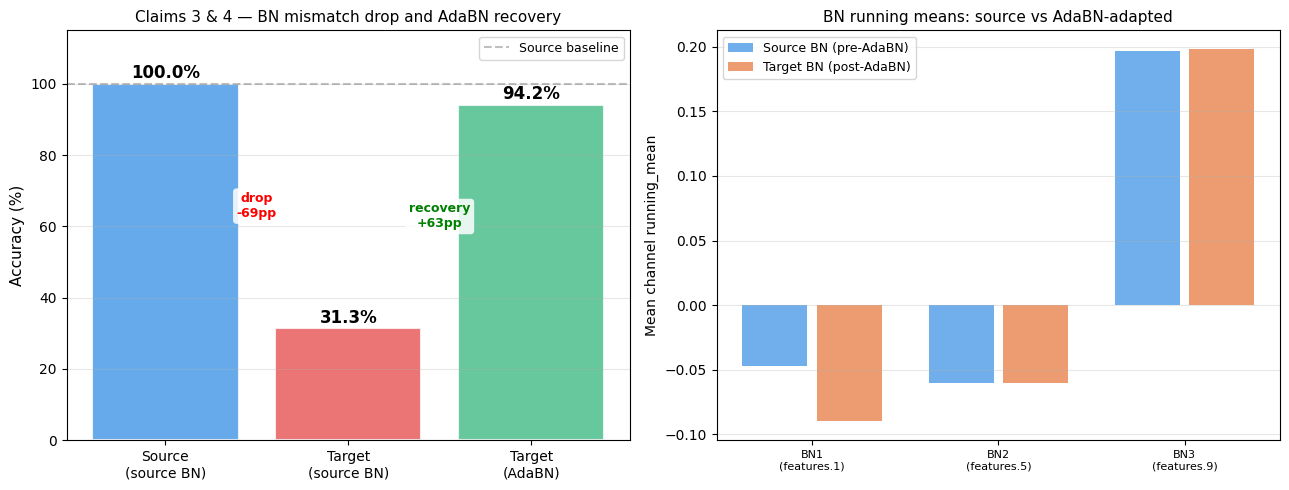

Saved: figures/claims3_4_adabn.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: accuracy comparison bar chart
ax = axes[0]
labels = ['Source\n(source BN)', 'Target\n(source BN)', 'Target\n(AdaBN)']
accs   = [src_test_acc * 100, tgt_acc_src_bn * 100, tgt_acc_adabn * 100]
colors = ['#4c9be8', '#e85c5c', '#4cbe8c']
bars   = ax.bar(labels, accs, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Claims 3 & 4 — BN mismatch drop and AdaBN recovery', fontsize=11)
ax.set_ylim([0, 115])
ax.axhline(src_test_acc * 100, color='gray', ls='--', alpha=0.5, label='Source baseline')
ax.grid(alpha=0.3, axis='y')
ax.legend(fontsize=9)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, acc + 1.5,
            f'{acc:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Drop / recovery annotations between bars
bbox_kw = dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.85)
ax.text(0.5, (accs[0] + accs[1]) / 2,
        f'drop\n-{accs[0]-accs[1]:.0f}pp',
        ha='center', va='center', fontsize=9, color='red', fontweight='bold', bbox=bbox_kw)
ax.text(1.5, (accs[1] + accs[2]) / 2,
        f'recovery\n+{accs[2]-accs[1]:.0f}pp',
        ha='center', va='center', fontsize=9, color='green', fontweight='bold', bbox=bbox_kw)

# Right: BN running means before vs after AdaBN
ax = axes[1]
src_rm, ada_rm, bn_labels = [], [], []
for (n, m1), (_, m2) in zip(model.named_modules(), model_adabn.named_modules()):
    if isinstance(m1, nn.BatchNorm2d):
        src_rm.append(m1.running_mean.cpu().numpy().mean())
        ada_rm.append(m2.running_mean.cpu().numpy().mean())
        bn_labels.append(n)

xp = np.arange(len(bn_labels))
ax.bar(xp - 0.2, src_rm, 0.35, label='Source BN (pre-AdaBN)',  color='#4c9be8', alpha=0.8)
ax.bar(xp + 0.2, ada_rm, 0.35, label='Target BN (post-AdaBN)', color='#e8844c', alpha=0.8)
ax.set_xticks(xp)
ax.set_xticklabels([f'BN{i+1}\n({bn_labels[i]})' for i in range(len(bn_labels))], fontsize=8)
ax.set_ylabel('Mean channel running_mean', fontsize=10)
ax.set_title('BN running means: source vs AdaBN-adapted', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'claims3_4_adabn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/claims3_4_adabn.png')

In [11]:
sep = '=' * 64
print(sep)
print('EXPERIMENTAL RESULTS SUMMARY')
print(sep)
print()
print('Claim 1  — Intensity shift is a reasonable approximation of a real distribution shift')
print(f'  Mean shift  : {mean_shift:.4f}')
print(f"  Cohen's d   : {cohens_d:.2f}  (|d| > 0.8 is a large effect)")
print(f'  KS p-value  : {ks_p:.2e}  (rejects same-distribution at p < 0.05)')
print()
print('Claim 2  — CNN with BN performs well on source domain')
print(f'  Source test accuracy          : {src_test_acc*100:.1f}%')
print()
print('Claim 3  — BN statistics mismatch causes performance degradation')
print(f'  Target accuracy (source BN)   : {tgt_acc_src_bn*100:.1f}%')
print(f'  Accuracy drop                 : {(src_test_acc - tgt_acc_src_bn)*100:.1f} pp')
print()
print('Claim 4  — AdaBN recovers target-domain performance')
print(f'  Target accuracy (AdaBN)       : {tgt_acc_adabn*100:.1f}%')
print(f'  Recovery                      : +{(tgt_acc_adabn - tgt_acc_src_bn)*100:.1f} pp')
print(sep)

EXPERIMENTAL RESULTS SUMMARY

Claim 1  — Intensity shift is a reasonable approximation of a real distribution shift
  Mean shift  : 0.2988
  Cohen's d   : 2.11  (|d| > 0.8 is a large effect)
  KS p-value  : 0.00e+00  (rejects same-distribution at p < 0.05)

Claim 2  — CNN with BN performs well on source domain
  Source test accuracy          : 100.0%

Claim 3  — BN statistics mismatch causes performance degradation
  Target accuracy (source BN)   : 31.3%
  Accuracy drop                 : 68.7 pp

Claim 4  — AdaBN recovers target-domain performance
  Target accuracy (AdaBN)       : 94.2%
  Recovery                      : +62.8 pp
